## Full Workflow

In [1]:
# house pricing dataset
from fairlearn.datasets import fetch_boston
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load data

In [2]:
X, y = fetch_boston(return_X_y=True, as_frame=True)
X.shape, y.shape

c:\Users\Admin\miniconda3\envs\fcc\Lib\site-packages\fairlearn\datasets\_fetch_boston.py:133: DataFairnessWarning: You are about to use a dataset with known fairness issues.
  warnings.warn(DataFairnessWarning(msg))


((506, 13), (506,))

In [3]:
df = pd.concat([X, y], axis=1)
df.sample(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
297,0.14103,0.0,13.92,0,0.437,5.790,58.0,6.3200,4,289.0,16.0,396.90,15.84,20.3
368,4.89822,0.0,18.10,0,0.631,4.970,100.0,1.3325,24,666.0,20.2,375.52,3.26,50.0
343,0.02543,55.0,3.78,0,0.484,6.696,56.4,5.7321,5,370.0,17.6,396.90,7.18,23.9
70,0.08826,0.0,10.81,0,0.413,6.417,6.6,5.2873,4,305.0,19.2,383.73,6.72,24.2
260,0.54011,20.0,3.97,0,0.647,7.203,81.8,2.1121,5,264.0,13.0,392.80,9.59,33.8


### 2. Add missing values and categorical features for demonstration

In [4]:
# Add missing values and categorical features for demonstration

df.loc[0:9, "RM"] = np.nan
df["CHAS"] = df["CHAS"].astype(str)  # nominal
df["AGE_cat"] = pd.cut(df["AGE"], bins=[0, 35, 70, 100], labels=["young", "middle", "old"])  # ordinal
df.sample(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,AGE_cat
408,7.40389,0.0,18.10,0,0.597,5.617,97.9,1.4547,24,666.0,20.2,314.64,26.40,17.2,old
271,0.16211,20.0,6.96,0,0.464,6.240,16.3,4.4290,3,223.0,18.6,396.90,6.59,25.2,young
41,0.12744,0.0,6.91,0,0.448,6.770,2.9,5.7209,3,233.0,17.9,385.41,4.84,26.6,young
488,0.15086,0.0,27.74,0,0.609,5.454,92.7,1.8209,4,711.0,20.1,395.09,18.06,15.2,old
452,5.09017,0.0,18.10,0,0.713,6.297,91.8,2.3682,24,666.0,20.2,385.09,17.27,16.1,old


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    object  
 4   NOX      506 non-null    float64 
 5   RM       496 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
 14  AGE_cat  506 non-null    category
dtypes: category(2), float64(12), object(1)
memory usage: 53.0+ KB


In [6]:
num_features = df.select_dtypes(include=np.number).columns.tolist()
num_features.remove("MEDV")
cat_nominal = ["CHAS"]
cat_ordinal = ["AGE_cat", "RAD"]

num_features, cat_nominal, cat_ordinal

(['CRIM',
  'ZN',
  'INDUS',
  'NOX',
  'RM',
  'AGE',
  'DIS',
  'TAX',
  'PTRATIO',
  'B',
  'LSTAT'],
 ['CHAS'],
 ['AGE_cat', 'RAD'])

### 3. Handle missing values

In [7]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

In [8]:
# Drop rows/columns

# df_dropna = df.dropna(subset=["RM"])
# df_dropna = df_dropna.drop(columns=["AGE"])

In [9]:
# Simple imputation: median, mean, mode

imputer = SimpleImputer(strategy="median")   # strategy="mean", strategy="most_frequent"
df[num_features] = imputer.fit_transform(df[num_features])
df["RM"].to_list()[:10]

[6.205, 6.205, 6.205, 6.205, 6.205, 6.205, 6.205, 6.205, 6.205, 6.205]

In [10]:
imputer.statistics_

array([2.56510e-01, 0.00000e+00, 9.69000e+00, 5.38000e-01, 6.20500e+00,
       7.75000e+01, 3.20745e+00, 3.30000e+02, 1.90500e+01, 3.91440e+02,
       1.13600e+01])

In [11]:
# IterativeImputer

df.loc[0:9, "RM"] = np.nan
imputer = IterativeImputer(max_iter=10, random_state=42)
df[num_features] = imputer.fit_transform(df[num_features])
df["RM"].round(3).to_list()[:10]

[7.012, 6.499, 6.732, 6.726, 6.617, 6.655, 6.331, 6.048, 5.356, 6.102]

In [12]:
# KNNImputer

df.loc[0:9, "RM"] = np.nan
imputer = KNNImputer(n_neighbors=5)
df[num_features] = imputer.fit_transform(df[num_features])
df["RM"].round(3).to_list()[:10]

[6.362, 6.1, 6.151, 6.108, 5.955, 5.864, 5.97, 6.123, 5.97, 6.051]

### 4. Low Variance Features

* VarianceThreshold is a simple baseline approach to feature selection. It removes all features whose variance doesn’t meet some threshold. 

In [13]:
df[num_features].shape

(506, 11)

In [14]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
df[num_features] = selector.fit_transform(df[num_features])

df[num_features].shape, df[num_features].columns.tolist()

((506, 11),
 ['CRIM',
  'ZN',
  'INDUS',
  'NOX',
  'RM',
  'AGE',
  'DIS',
  'TAX',
  'PTRATIO',
  'B',
  'LSTAT'])

### 5. Duplicates & Outliers

In [15]:
df = df.drop_duplicates()
df.shape

(506, 15)

**IQR (Interquartile Range Method)**

IQR = Q3 - Q1

Outliers = points outside
[Q1 − 1.5 ⋅ IQR, Q3 + 1.5 ⋅ IQR]

Pros:
* Simple, fast, intuitive.
* Works well for small datasets or when distribution is roughly symmetric.

Cons:
* Univariate → looks at each feature separately, not relationships between features.
* May remove too many points if data is skewed.

In [16]:
# IQR method

Q1 = df[num_features].quantile(0.25)
Q3 = df[num_features].quantile(0.75)
IQR = Q3 - Q1
df_out = df[~((df[num_features] < (Q1 - 1.5 * IQR)) | (df[num_features] > (Q3 + 1.5 * IQR))).any(axis=1)]
df_out.shape


(298, 15)

**Z-score Method**

Outliers = points where threshold ∣Z∣ > threshold (commonly 3).
$$
  Z = \frac{x - \mu}{\sigma}
$$
Pros:
* Good for normally distributed data.
* Easy to compute.

Cons:
* Sensitive to mean/variance — extreme values can distort μ and σ.
* Univariate.	​


In [17]:
# Z-score method

from scipy.stats import zscore

z_scores = np.abs(zscore(df[num_features + ["MEDV"]]))
df_out_z = df[(z_scores < 3).all(axis=1)]
df_out_z.shape


(447, 15)

**Isolation Forest**

Builds many random trees. Outliers are easier to isolate.

Pros:
* Works in high dimensions (multivariate).
* Captures complex relationships between features.
* Robust to skewed distributions.

Cons:
* More computationally expensive than IQR/Z-score.
* Requires tuning (number of trees, contamination fraction).
* Less interpretable than IQR/Z-score.

In [18]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
outliers = iso.fit_predict(df[num_features])
outliers[:20]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [19]:
df_iso = df[outliers == 1]
df_iso.shape

(480, 15)

### 6. Feature Scaling

**Standarization (Z-score scaling)**
$$
x' = \frac{x - \mu}{\sigma}
$$

Python: df["col_standardized"] = (df["col"] - df["col"].mean()) / df["col"].std()


**Normalization (Min-Max scaling)**
$$
x' = \frac{x - \min(x)}{\max(x) - \min(x)}
$$

Python: df["col_normalized"] = (df["col"] - df["col"].min()) / (df["col"].max() - df["col"].min())

In [20]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer

In [21]:
# StandardScaler - standarization

df_scaler = df.copy()

scaler_std = StandardScaler()
df[num_features] = scaler_std.fit_transform(df[num_features])

In [22]:
# MinMaxScaler - normalization

scaler_mm = MinMaxScaler()
df_scaler[num_features] = scaler_mm.fit_transform(df_scaler[num_features])

The power transform method. Available methods are:
* ‘yeo-johnson’, works with positive and negative values
* ‘box-cox’, only works with strictly positive values

In [23]:
# PowerTransformer

pt = PowerTransformer(method="yeo-johnson")
df[num_features] = pt.fit_transform(df[num_features])

* **Right skew (positive skew)**: try log / sqrt / Box-Cox / Yeo-Johnson
* **Left skew (negative skew)**: try exp / square / Yeo-Johnson
* If data contains **zeros or negatives** → go with Yeo-Johnson, since log/Box-Cox won’t work.

### 7. Encoding Categorical Features

In [24]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [25]:
ohe = OneHotEncoder(drop="first", sparse_output=False)
encoded_nom = pd.DataFrame(
    ohe.fit_transform(df[cat_nominal]), columns=ohe.get_feature_names_out(cat_nominal)
)
df = pd.concat([df.drop(columns=cat_nominal), encoded_nom], axis=1)
df.head(3)

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,AGE_cat,CHAS_1
0,-0.813375,1.403408,-1.407521,0.040293,0.179614,-0.370107,0.441615,1,-0.599226,-1.359729,0.883284,-1.269381,24.0,middle,0.0
1,-0.796420,-0.596367,-0.528409,-0.722272,-0.202831,0.182925,0.802803,2,-1.180532,-0.549654,0.883284,-0.382304,21.6,old,0.0
2,-0.796436,-0.596367,-0.528409,-0.722272,-0.125417,-0.506282,0.802803,2,-1.180532,-0.549654,0.546266,-1.496248,34.7,middle,0.0


In [26]:
ord_enc = OrdinalEncoder()
df[cat_ordinal] = ord_enc.fit_transform(df[cat_ordinal])
df.head(3)

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,AGE_cat,CHAS_1
0,-0.813375,1.403408,-1.407521,0.040293,0.179614,-0.370107,0.441615,0.0,-0.599226,-1.359729,0.883284,-1.269381,24.0,0.0,0.0
1,-0.796420,-0.596367,-0.528409,-0.722272,-0.202831,0.182925,0.802803,1.0,-1.180532,-0.549654,0.883284,-0.382304,21.6,1.0,0.0
2,-0.796436,-0.596367,-0.528409,-0.722272,-0.125417,-0.506282,0.802803,1.0,-1.180532,-0.549654,0.546266,-1.496248,34.7,0.0,0.0


### 8. Feature Selection & Redundancy Reduction

In [27]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV', 'AGE_cat', 'CHAS_1'],
      dtype='object')

In [28]:
# Correlation filtering

X = df.drop(columns=["MEDV"])
y = df["MEDV"]

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.86)] # > 0.9

to_drop_corr

['DIS']

In [29]:
upper

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,AGE_cat,CHAS_1
CRIM,NaN,0.431684,0.702566,0.748768,0.285607,0.609097,0.683669,0.456745,0.833196,0.437071,0.475252,0.578420,0.007953,0.002174
ZN,NaN,NaN,0.617055,0.616622,0.341017,0.548737,0.624126,0.169822,0.388391,0.450848,0.235380,0.475971,0.198741,0.039744
INDUS,NaN,NaN,NaN,0.790692,0.397966,0.680643,0.764211,0.301467,0.706030,0.446285,0.398685,0.633178,0.006498,0.070858
NOX,NaN,NaN,NaN,NaN,0.311011,0.798482,0.877728,0.231028,0.657998,0.338602,0.399407,0.619266,0.097460,0.077405
RM,NaN,NaN,NaN,NaN,NaN,0.265866,0.262730,0.157523,0.293648,0.336149,0.160330,0.630579,0.067484,0.087391
AGE,NaN,NaN,NaN,NaN,NaN,NaN,0.798896,0.192067,0.527063,0.342012,0.319716,0.641245,0.109007,0.078293
DIS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.247992,0.595214,0.303147,0.343263,0.553838,0.073404,0.082629
RAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.324554,0.310741,0.151749,0.245471,0.013131,0.076745
TAX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.463747,0.420595,0.530001,0.063898,0.038255
PTRATIO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.138540,0.444109,0.052240,0.131905


In [30]:
df = df.drop(columns=to_drop_corr)
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'RAD', 'TAX', 'PTRATIO', 'B',
       'LSTAT', 'MEDV', 'AGE_cat', 'CHAS_1'],
      dtype='object')

In [31]:
# Multicollinearity check

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop(columns=["MEDV"])
X_const = sm.add_constant(X)

vif_data = pd.DataFrame(
    {
        "feature": X_const.columns,
        "VIF": [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])],
    }
)

In [32]:
vif_data

,feature,VIF
0,const,8.574609
1,CRIM,5.391153
2,ZN,2.089105
3,INDUS,3.901041
4,NOX,5.322795
5,RM,1.838935
6,AGE,3.264897
7,RAD,1.388676
8,TAX,3.951389
9,PTRATIO,1.650086


In [33]:
high_vif = vif_data[vif_data["VIF"] > 10]["feature"].tolist()

In [34]:
df = df.drop(columns=high_vif)

In [35]:
# Model-based selection (RFE + Lasso)

# Lasso - pushes some coefficients exactly to 0
# RFE - Recursive Feature Elimination - iteratively removes the least important features until only the desired number remains
# Steps:
#  1. Fit model (Lasso).
#  2. Rank features by importance (magnitude of coefficients in Lasso).
#  3. Remove the least important feature(s).
#  4. Repeat until n_features_to_select=5.

from sklearn.linear_model import Lasso
from sklearn.feature_selection import RFE

X = df.drop("MEDV", axis=1)
y = df["MEDV"]

lasso = Lasso(alpha=0.01, random_state=42)
rfe = RFE(lasso, n_features_to_select=5)
rfe.fit(X, y)

X.columns[rfe.support_]

Index(['RM', 'AGE', 'PTRATIO', 'LSTAT', 'CHAS_1'], dtype='object')

In [36]:
rfe.support_, rfe.ranking_

(array([False, False, False, False,  True,  True, False, False,  True,
        False,  True, False,  True]),
 array([3, 7, 9, 4, 1, 1, 5, 2, 1, 6, 1, 8, 1]))

In [37]:
X = X[X.columns[rfe.support_]]
X.head(3)

,RM,AGE,PTRATIO,LSTAT,CHAS_1
0,0.179614,-0.370107,-1.359729,-1.269381,0.0
1,-0.202831,0.182925,-0.549654,-0.382304,0.0
2,-0.125417,-0.506282,-0.549654,-1.496248,0.0


### 9. Linear Regression Training

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((404, 5), (102, 5), (404,), (102,))

In [40]:
X_train_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.719
Method:                 Least Squares   F-statistic:                     206.9
Date:                Tue, 16 Sep 2025   Prob (F-statistic):          2.72e-108
Time:                        13:14:51   Log-Likelihood:                -1216.4
No. Observations:                 404   AIC:                             2445.
Df Residuals:                     398   BIC:                             2469.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.2180      0.256     86.846      0.0

Text(0.5, 1.0, 'Residuals Distribution')

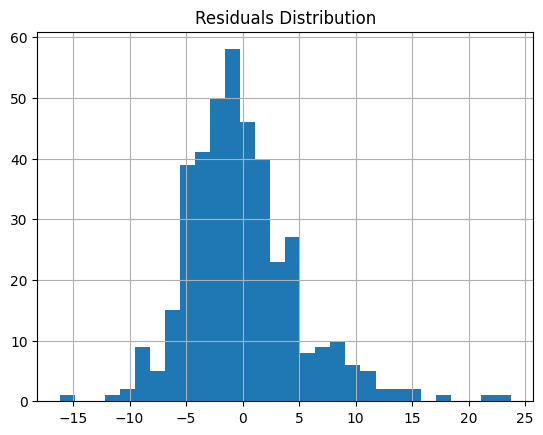

In [41]:
residuals = model.resid
residuals.hist(bins=30)
plt.title("Residuals Distribution")

In [42]:
y_pred = model.predict(X_train_const)

Shapiro-Wilk p-value (residual normality): 4.774690645148092e-10


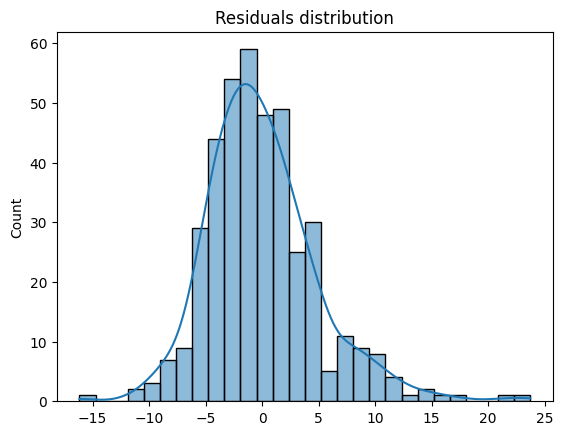

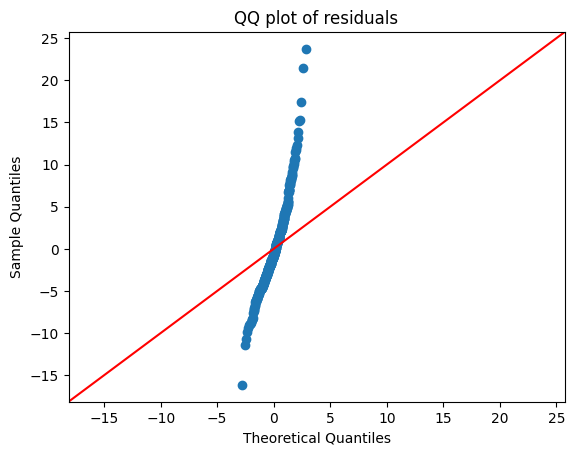

In [43]:
from scipy.stats import shapiro

stat, p = shapiro(residuals)
print("Shapiro-Wilk p-value (residual normality):", p)
sns.histplot(residuals, kde=True)
plt.title("Residuals distribution")
plt.show()
sm.qqplot(residuals, line="45")
plt.title("QQ plot of residuals")
plt.show()

Possible actions:

* Check whether the issue is caused by individual observations:
    * Calculate Cook’s distance and identify which points are influential.
    * You can remove them or verify whether they are data entry errors.

* Consider transforming the target variable (TARGET):
    * For example, use np.log1p(TARGET) – this reduces skewness and often improves the normality of residuals.
    * After transformation, refit the model and run the Shapiro–Wilk test again.

* Consider models robust to non-normality:
    * Use robust standard errors (HC3): model.get_robustcov_results(cov_type='HC3')
    * Or try robust regression: sm.RLM(y, X).fit()

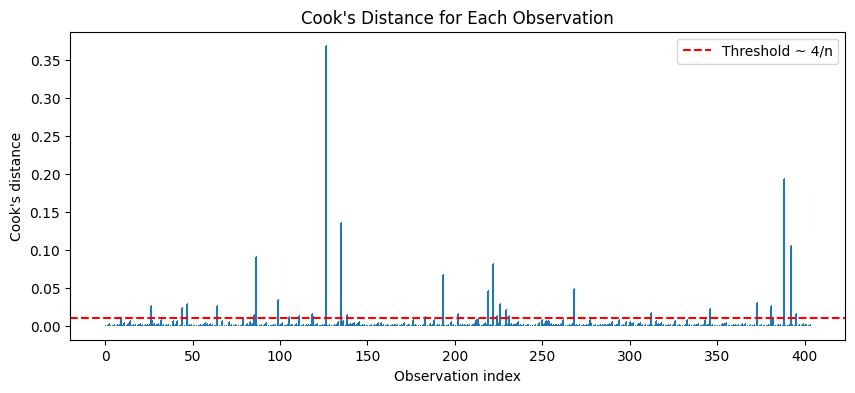

Number of high impact observations: 34
Influential Observation Indexes: [  9  26  44  47  64  79  85  86  99 105 111 118 119 126 135 138 183 193
 202 219 222 224 226 229 231 268 312 346 373 381 382 388 392 395]


In [44]:
# Cook's Distance

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import OLSInfluence

influence = OLSInfluence(model)
cooks_d = influence.cooks_distance[0]

# Cook's distance
plt.figure(figsize=(10, 4))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",", basefmt=" ")
plt.axhline(4 / len(cooks_d), color="red", linestyle="--", label="Threshold ~ 4/n")
plt.title("Cook's Distance for Each Observation")
plt.xlabel("Observation index")
plt.ylabel("Cook's distance")
plt.legend()
plt.show()

# Display observations above threshold
threshold = 4 / len(cooks_d)
influential_points = np.where(cooks_d > threshold)[0]
print(f"Number of high impact observations: {len(influential_points)}")
print("Influential Observation Indexes:", influential_points)

In [45]:
y_train = np.log1p(y_train)

model = sm.OLS(y_train, X_train_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.731
Model:                            OLS   Adj. R-squared:                  0.727
Method:                 Least Squares   F-statistic:                     216.2
Date:                Tue, 16 Sep 2025   Prob (F-statistic):          4.86e-111
Time:                        13:14:52   Log-Likelihood:                 72.900
No. Observations:                 404   AIC:                            -133.8
Df Residuals:                     398   BIC:                            -109.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0737      0.011    292.183      0.0

Shapiro-Wilk p-value (residual normality): 6.42655609029748e-05


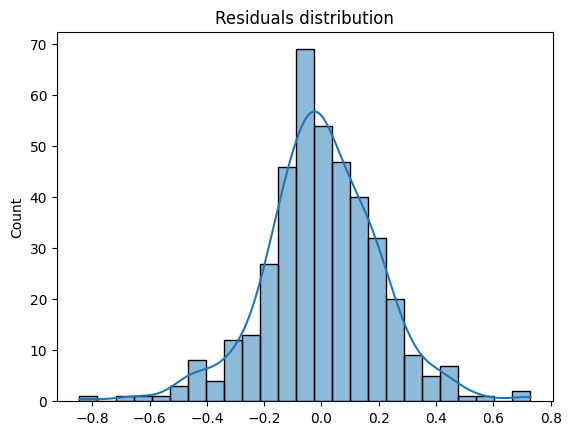

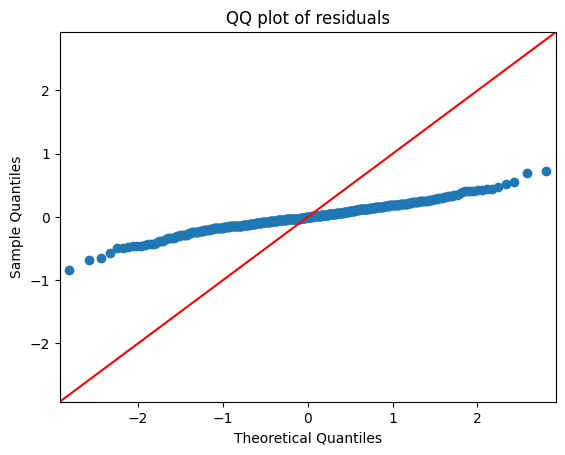

In [46]:
residuals = model.resid

stat, p = shapiro(residuals)
print("Shapiro-Wilk p-value (residual normality):", p)
sns.histplot(residuals, kde=True)
plt.title("Residuals distribution")
plt.show()
sm.qqplot(residuals, line="45")
plt.title("QQ plot of residuals")
plt.show()

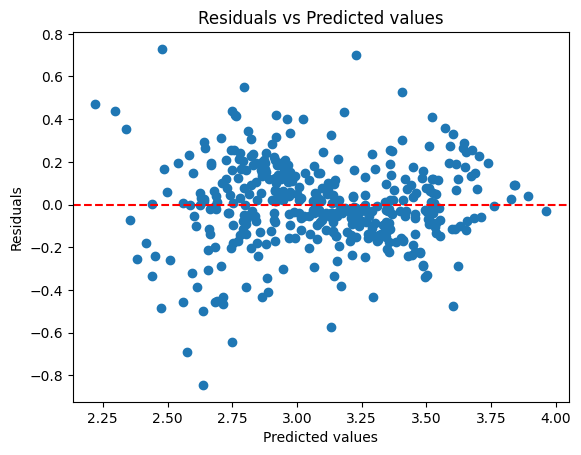

In [47]:
residuals = y_train - model.predict(X_train_const)
plt.scatter(model.predict(X_train_const), residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted values")
plt.show()